# 45 — The two fields of a paradigm: conservatism and conviction on the dark-energy turn

**What this adds.** nb44 ran a *population* tracking a changing cosmology and found the lock-in
needs two levers (conviction **and** disconnection). This notebook opens the single agent's
paradigm net and shows the **geometry that drives all of it** — the modeling lens of the paper,
made concrete on the 1998 dark-energy turn. One directed Bayes net wires the whole thing, and
*three faces of a single fact* fall out of it as linear algebra:

1. **Directed SEM is primary.** The agent holds a generative model `x = B·x + ζ` — general
   relativity at the root, every predicted observable hanging below it. The undirected "coherence"
   precision everyone draws is its **shadow**, recovered exactly by `Π = (I−B)ᵀ D⁻¹ (I−B)`. We
   *generate and propagate* with the directed form and *read coherence* off the symmetric one.
2. **One operator, two fields.** The propagation operator `T = (I−B)⁻¹` applied to the **unit
   source** gives **conservatism** `κ = T·1` (the carry-over cost of revising a commitment — why
   the field flips the cheap dial Λ and not the expensive ancestor GR); applied to the **value
   source** it gives **conviction** `U = T·u` (the value a commitment inherits from the cherished
   observations below it). They are `T·1` and `T·u` — *linearly independent*: Λ is **cheap yet
   cherished**, GR **central yet value-neutral**.
3. **The Schur degeneracy.** Ω_m and Λ are independent a priori; **condition on the shared
   supernova observation** and an off-diagonal coupling appears between them — the tilted "banana"
   every dark-energy contour plot draws and calls *the degeneracy direction*. A shared latent hub
   marginalized, or a shared observation conditioned on, are the two readings of one Schur complement.

**And then the bridge:** those two fields are exactly the two **population levers** of nb44 —
conservatism is the prior *stiffness* that makes tracking lag, conviction is the value *tilt* that
makes it lock in — and model **expansion** (waking an unconceived Λ node) is the 1998 discovery itself.

> ### ⚠️ Disclaimers
> * **Stylized model, not real cosmology.** The DAG below is an *illustrative* paradigm net; the
>   weights are chosen to expose the geometry, not fit data. Nothing here is evidence about actual
>   cosmology — it is a model of *how a structured commitment resists and reorganizes*.
> * **κ and U use coupling magnitudes** (the paper's positive coupling precisions `π_uv`); the
>   *signs* of the structural weights (matter vs Λ entering the expansion oppositely) live in the
>   Gaussian `Π` and drive the Schur banana. Two distinct, deliberate roles for `B`.
> * The population panels (§5–6) **load** the arrays written by `run_cosmology_tracking.py` /
>   `run_cosmology_regrowth.py`; run those scripts first.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
ROOT = ROOT if (ROOT / 'scripts').exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np

# Import ALL the script helpers up front. Each script calls matplotlib.use('Agg') at import
# time (they render headless), so we re-assert %matplotlib inline AFTER these imports and do
# no further script imports below -- otherwise a later import would silently switch us back to
# Agg and the figures would not render in the notebook.
from scripts.run_cosmology_twofield import (
    build_dark_energy_dag, conservatism, conviction, utility_vector, schur_banana,
    propagation_operator, draw_dag, _short, NODES)
from scripts.run_cosmology_tracking import COMM_LABELS, HOMES, EPOCH_NAMES, T1, T2
from scripts.run_cosmology_regrowth import TRIGGER

%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

net = build_dark_energy_dag()
names = list(net.names)
kap = conservatism(net); U = conviction(net); u = utility_vector()
i_gr, i_lam = names.index('general_relativity'), names.index('dark_energy')
print('%d-node dark-energy DAG' % len(names))
print('kappa(GR)=%.2f  kappa(Lambda)=%.2f  ratio=%.2f' % (kap[i_gr], kap[i_lam], kap[i_gr]/kap[i_lam]))
print('U(Lambda)=%.2f  U(GR)=%.2f  (value order inverts cost order)' % (U[i_lam], U[i_gr]))

17-node dark-energy DAG
kappa(GR)=10.50  kappa(Lambda)=2.85  ratio=3.68
U(Lambda)=1.19  U(GR)=0.45  (value order inverts cost order)


## 1 — Directed SEM primary, the symmetric precision its shadow

The agent's model is a **directed** structural-equation model `x = B·x + ζ`, `ζ ~ N(0, D)`: each
commitment is a noisy function of its parents, GR at the root. `B[child, parent]` is the coupling
weight (left panel). The undirected coherence picture — the precision matrix `Π` the dynamics
actually consume — is **derived** from it by the exact bridge

$$\Pi = (I-B)^{\top} D^{-1} (I-B)$$

(`bayesnet.to_info`; right panel). The directed form says *how the world generates what we see*;
the symmetric form is what that model looks like when you forget the arrows. Reading them as
*primary* and *shadow* (rather than two separate objects) is the seam the paper makes explicit.

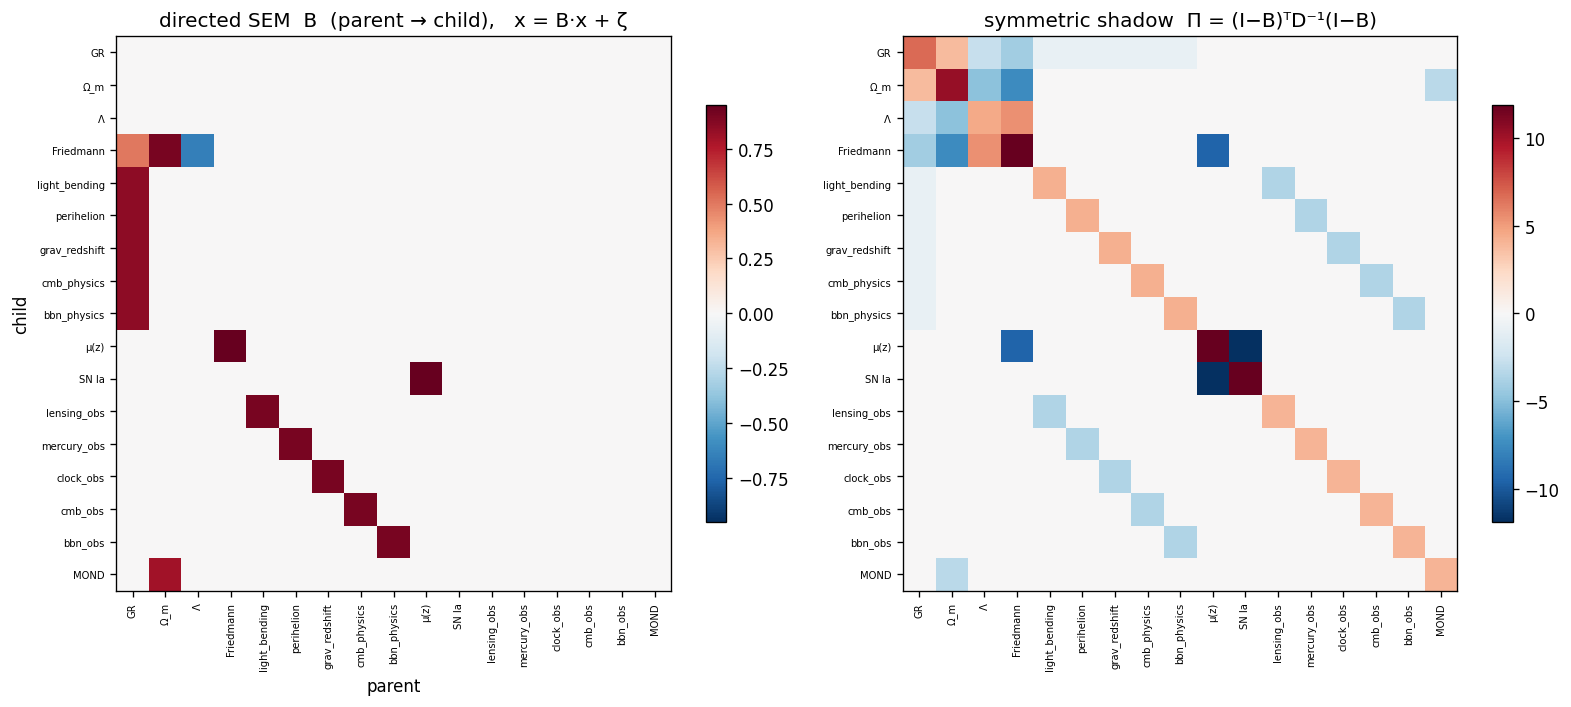

B is strictly lower-triangular (a DAG, parents before children); Π is its symmetric image.


In [2]:
B = np.asarray(net.B); Pi = np.asarray(net.to_info().Pi)
short = [_short(n) for n in names]
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13.5, 5.8))
m = np.abs(B).max()
im0 = a0.imshow(B, cmap='RdBu_r', vmin=-m, vmax=m)
a0.set_title('directed SEM  B  (parent → child),   x = B·x + ζ')
a0.set_xlabel('parent'); a0.set_ylabel('child')
pm = np.abs(Pi - np.diag(np.diag(Pi))).max()
im1 = a1.imshow(Pi, cmap='RdBu_r', vmin=-pm, vmax=pm)
a1.set_title('symmetric shadow  Π = (I−B)ᵀD⁻¹(I−B)')
for ax, im in ((a0, im0), (a1, im1)):
    ax.set_xticks(range(len(names))); ax.set_xticklabels(short, rotation=90, fontsize=6)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(short, fontsize=6)
    ax.grid(False); fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()
print('B is strictly lower-triangular (a DAG, parents before children); Π is its symmetric image.')

## 2 — Conservatism `κ = T·1`: why the field flips Λ, not GR

Push the **unit source** through the propagation operator `T = (I−B)⁻¹` and you get each node's
**downstream mass** — `κ_i = 1 + Σ_{w∈desc(i)} π_{i⇝w}`, the precision-weighted total of everything
that depends on it. That is the **carry-over cost** of revising the commitment: revise GR and *every
predicted observable* in the model has to be re-read, so `κ(GR)` is enormous; Λ sits above only the
distance–redshift branch, so `κ(Λ)` is tiny. When the 1998 supernova anomaly arrives at the bottom,
the field does the **cheap** thing — it moves the dial with the smallest descendant set (Λ) rather
than the ancestor with the largest (GR). **Lakatos's belt-protects-core, falling straight out of the
operator.** (Left DAG below: GR is hot, the leaves are cold.)

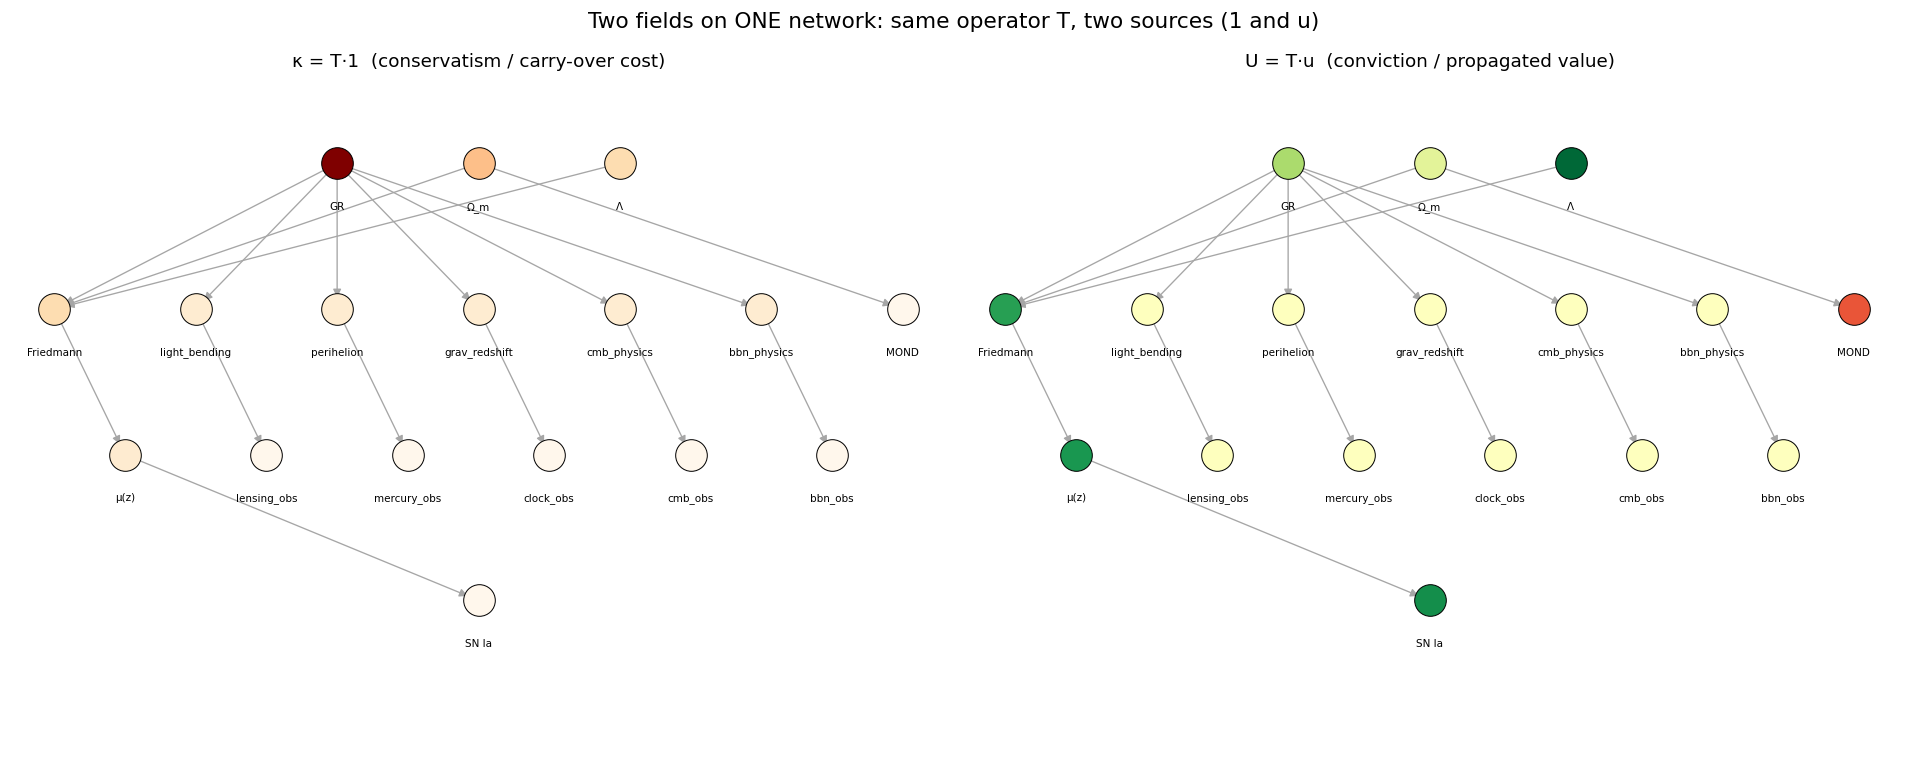

conservatism ranking (κ = downstream mass):
      general_relativity: κ=10.50
          matter_density: κ= 4.37
             dark_energy: κ= 2.85
     friedmann_expansion: κ= 2.85
        distance_modulus: κ= 1.95
           light_bending: κ= 1.90


In [3]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(16, 6.4))
draw_dag(net, kap, a0, cmap='OrRd',
         title='κ = T·1  (conservatism / carry-over cost)')
draw_dag(net, U, a1, cmap='RdYlGn', diverging=True,
         title='U = T·u  (conviction / propagated value)')
plt.suptitle('Two fields on ONE network: same operator T, two sources (1 and u)', fontsize=13)
plt.tight_layout(); plt.show()

order = np.argsort(-kap)
print('conservatism ranking (κ = downstream mass):')
for i in order[:6]:
    print(f'  {names[i]:>22}: κ={kap[i]:5.2f}')

## 3 — Conviction `U = T·u`: the second field, decoupled

Now push the **value source** `u` through the *same* operator. `u` is signed — the dark-energy
community **wants** the accelerating-universe supernova reading (`+1`), values the Λ commitment
itself (`+0.6`), and **wants the modified-gravity rival false** (`−0.8`); everything else is
value-neutral. `U = T·u` propagates that value **up to the ancestors** of the cherished leaves
(right DAG above: Λ and SN Ia green, MOND red, the GR machinery neutral).

The point is that `κ = T·1` and `U = T·u` are **the same operator on two different sources**, hence
linearly independent. The scatter makes the decoupling explicit:

* **Λ — cheap yet cherished**: low κ, highest U (it sits above the one branch the community cares about);
* **GR — central yet value-neutral**: highest κ, only modest U (most of its huge descendant set —
  lensing, Mercury, clocks, CMB, BBN — nobody has feelings about);
* **the GR machinery** (light-bending, perihelion, …): moderate κ, **zero** U;
* **MOND**: the rival the community wants *false* (U < 0).

The value order *inverts* the cost order — the cleanest possible witness that the two fields are not
the same thing wearing two hats.

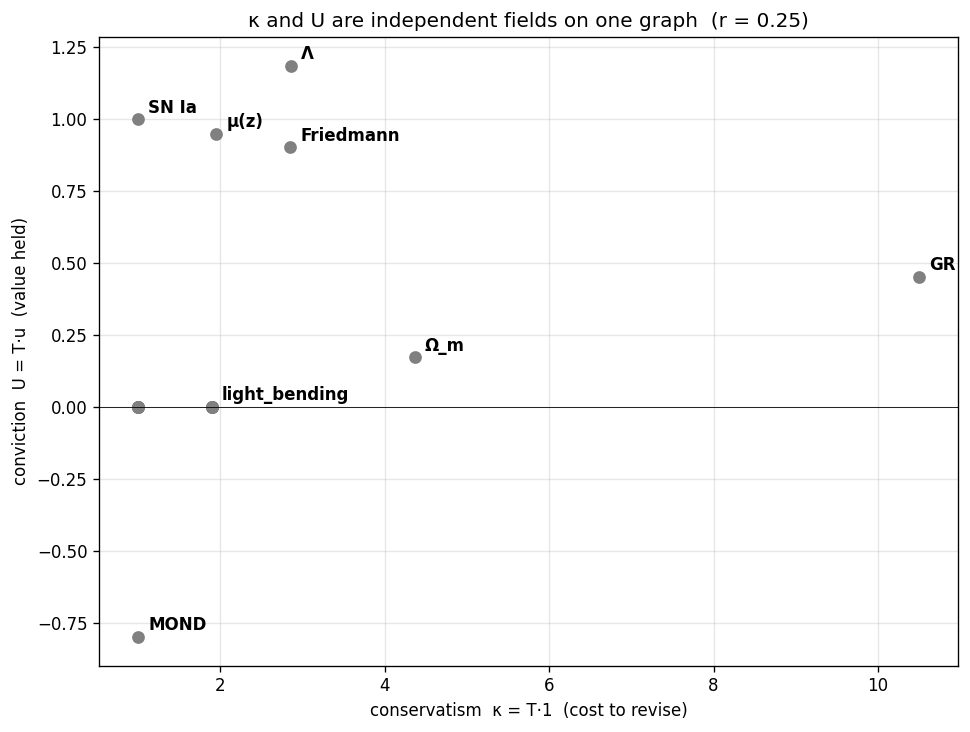

Λ:  κ=2.85 (low)  U=1.19 (max)   |   GR: κ=10.50 (max)  U=0.45 (modest)


In [4]:
fig, ax = plt.subplots(figsize=(8.2, 6.2))
ax.scatter(kap, U, s=44, color='0.5', zorder=2)
for n in ('general_relativity','dark_energy','matter_density','light_bending',
          'friedmann_expansion','supernova_obs','mond_prediction','distance_modulus'):
    i = names.index(n)
    ax.annotate(_short(n), (kap[i], U[i]), fontsize=10, fontweight='bold',
                textcoords='offset points', xytext=(6, 4))
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('conservatism  κ = T·1  (cost to revise)')
ax.set_ylabel('conviction  U = T·u  (value held)')
r = np.corrcoef(kap, U)[0, 1]
ax.set_title(f'κ and U are independent fields on one graph  (r = {r:.2f})')
plt.tight_layout(); plt.show()
print('Λ:  κ=%.2f (low)  U=%.2f (max)   |   GR: κ=%.2f (max)  U=%.2f (modest)'
      % (kap[i_lam], U[i_lam], kap[i_gr], U[i_gr]))

## 4 — The Schur degeneracy: conditioning manufactures the Ω_m–Λ banana

Ω_m and Λ enter the expansion with **opposite sign** (matter decelerates, Λ accelerates), so a
supernova that reads the distance–redshift relation constrains a *combination* of the two. A priori
the two dials are independent — the grey cloud is round, they tell you nothing about each other.
**Clamp the supernova node** (condition on the shared descendant) and the cloud collapses onto the
tilted **banana**: an off-diagonal coupling appears between Ω_m and Λ where the joint had a zero.
That is the Schur fill-in `−Π_ab Π_bb⁻¹ Π_ba` — and it is sitting in every dark-energy contour plot
ever published, where they call it *the degeneracy direction*. (Marginalizing a shared latent hub
induces the same coupling among its children — the two faces of one complement.)

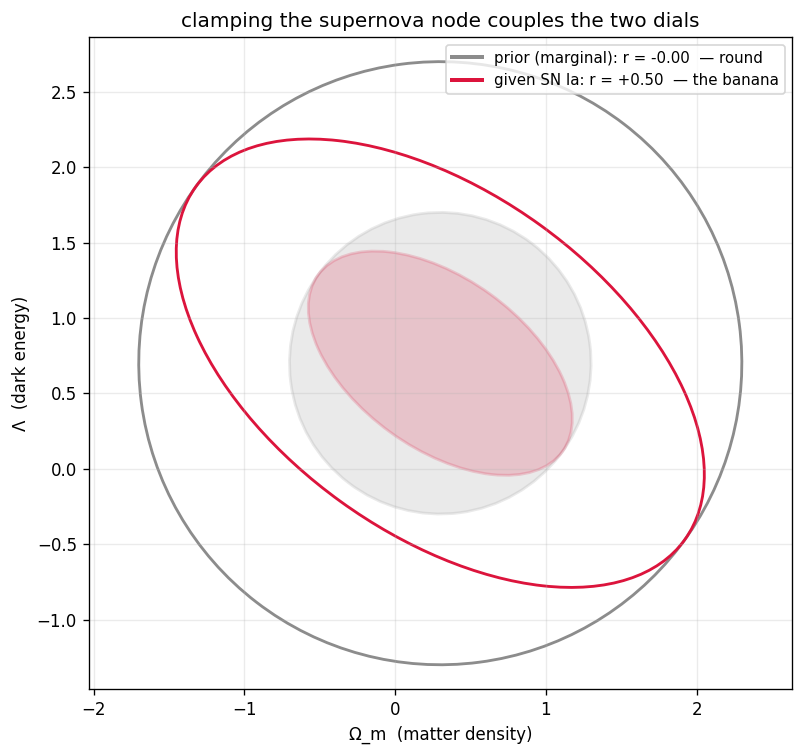

corr(Ω_m, Λ): prior -0.000  →  given SN 0.496


In [5]:
s = schur_banana(net); mu = (s['mu_a'], s['mu_b'])
def _ell(ax, Cv, color, lab):
    vals, vecs = np.linalg.eigh(Cv)
    ang = np.degrees(np.arctan2(vecs[1, np.argmax(vals)], vecs[0, np.argmax(vals)]))
    for k in (1.0, 2.0):
        w, h = 2*k*np.sqrt(np.maximum(vals, 1e-12))
        ax.add_patch(Ellipse(mu, w, h, angle=ang, fill=(k == 1.0),
                             alpha=0.18 if k == 1 else 1.0, edgecolor=color, facecolor=color, lw=1.7))
    ax.plot([], [], color=color, lw=2.4, label=lab)
fig, ax = plt.subplots(figsize=(6.8, 6.4))
_ell(ax, s['prior_cov'], '0.55', f"prior (marginal): r = {s['prior_corr']:.2f}  — round")
_ell(ax, s['post_cov'], 'crimson', f"given SN Ia: r = {s['post_corr']:+.2f}  — the banana")
ax.set_xlabel('Ω_m  (matter density)'); ax.set_ylabel('Λ  (dark energy)')
ax.set_title('clamping the supernova node couples the two dials')
ax.legend(loc='best', fontsize=9); ax.set_aspect('equal', 'datalim'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()
print('corr(Ω_m, Λ): prior %.3f  →  given SN %.3f' % (s['prior_corr'], s['post_corr']))

## 5 — The same two fields, at population scale (the bridge to nb44)

Everything above is **one agent's** geometry. nb44 lets a *population* of these agents track a world
that changes theory three times (dark matter → modified gravity → scale-variant). The two fields
become the two **levers** of that experiment:

| single-net field | population lever (nb44) | what it does |
|:--|:--|:--|
| **conservatism** `κ` | prior **stiffness** (a community's precision) + **disconnection** (trust precision `π_s`) | sets *how slowly* the core moves — the ~one-epoch tracking **lag** |
| **conviction** `U` | the per-community **value tilt** `h ← h + λ·U` toward its home theory | sets *whether* it moves at all — the **lock-in** |

The paper's slogan — *centrality sets how slowly the core moves; conviction sets whether it moves at
all* — is exactly the 2×2 below (loaded from `run_cosmology_tracking.py`). Each community's mean
belief is projected onto the three candidate theories; the grey staircase is the true theory.

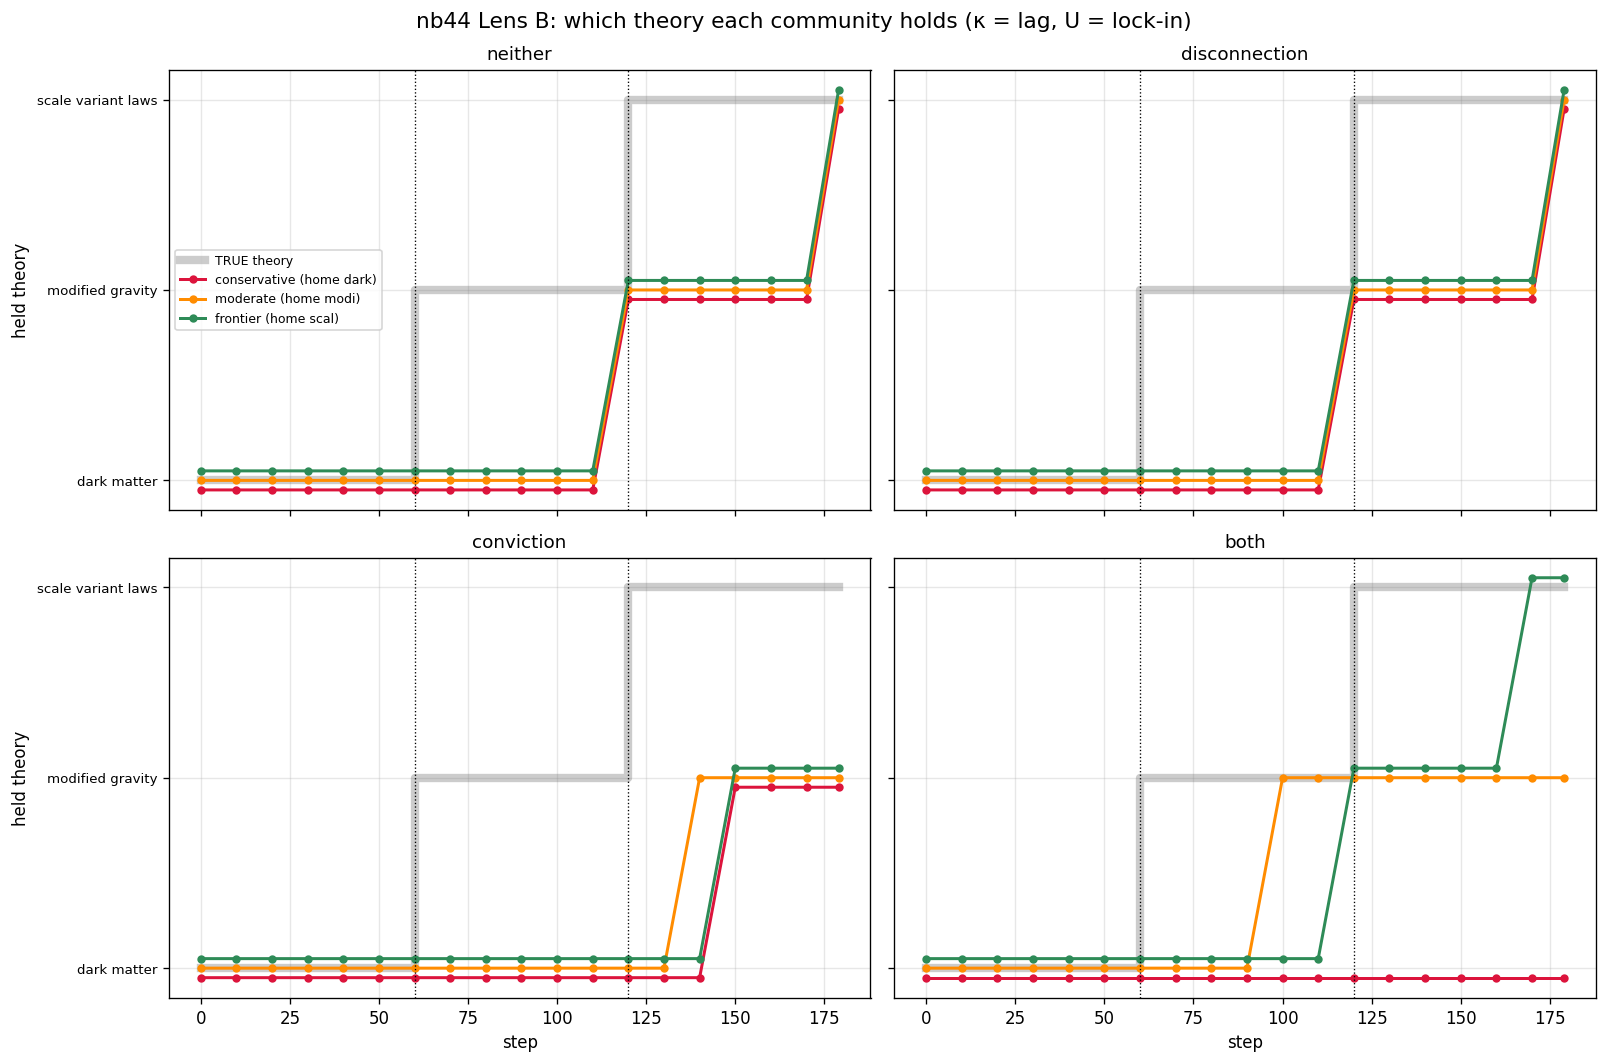

         neither: end-theories = [2, 2, 2]  (0=dark,1=modi,2=scale)
   disconnection: end-theories = [2, 2, 2]  (0=dark,1=modi,2=scale)
      conviction: end-theories = [1, 1, 1]  (0=dark,1=modi,2=scale)
            both: end-theories = [0, 1, 2]  (0=dark,1=modi,2=scale)


In [6]:
tr = np.load(ROOT / 'results' / 'cosmology_tracking' / 'simulation_arrays.npz', allow_pickle=True)
snap_t = tr['snap_t']; true_per = tr['true_per_snap']
cells = ['neither', 'disconnection', 'conviction', 'both']
held = {c: tr[f'held_{c}'] for c in cells}
cols = ['crimson', 'darkorange', 'seagreen']

fig, axs = plt.subplots(2, 2, figsize=(13.5, 9), sharex=True, sharey=True)
for ax, lab in zip(axs.ravel(), cells):
    ax.step(snap_t, true_per, where='post', color='0.35', lw=5, alpha=0.30, label='TRUE theory')
    h = held[lab]
    for k in range(h.shape[0]):
        ax.plot(snap_t, h[k] + 0.05*(k-1), 'o-', color=cols[k], lw=1.8, ms=4,
                label=f'{COMM_LABELS[k]} (home {HOMES[k][:4]})')
    for tt in (int(T1), int(T2)): ax.axvline(tt, color='k', ls=':', lw=0.8)
    ax.set_title(lab, fontsize=11)
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels([n.replace('_', ' ') for n in EPOCH_NAMES], fontsize=8)
axs[0, 0].set_ylabel('held theory'); axs[1, 0].set_ylabel('held theory')
axs[1, 0].set_xlabel('step'); axs[1, 1].set_xlabel('step')
axs[0, 0].legend(fontsize=7.5, loc='center left')
fig.suptitle('nb44 Lens B: which theory each community holds (κ = lag, U = lock-in)', fontsize=13)
plt.tight_layout(); plt.show()
for lab in cells:
    print(f'  {lab:>14}: end-theories = {[int(x) for x in held[lab][:, -1]]}  (0=dark,1=modi,2=scale)')

Read against the two fields: **neither / disconnection / conviction** all *re-track* (the
conservatism lag is visible — the curves trail the grey staircase by ~one epoch — but the belief
eventually follows). Only **both** locks in: the high-`κ` `conservative` bloc, its conviction tilted
to the old incumbent **and** shielded by disconnection, **freezes on dark matter forever** while the
others settle on their homes — the communities end on three different theories. Conviction alone
washes out under fusion (the no-pool degeneracy); it needs disconnection to hold. The structural
diversity (`residual_disagreement`) stays high exactly in the disconnected cells:

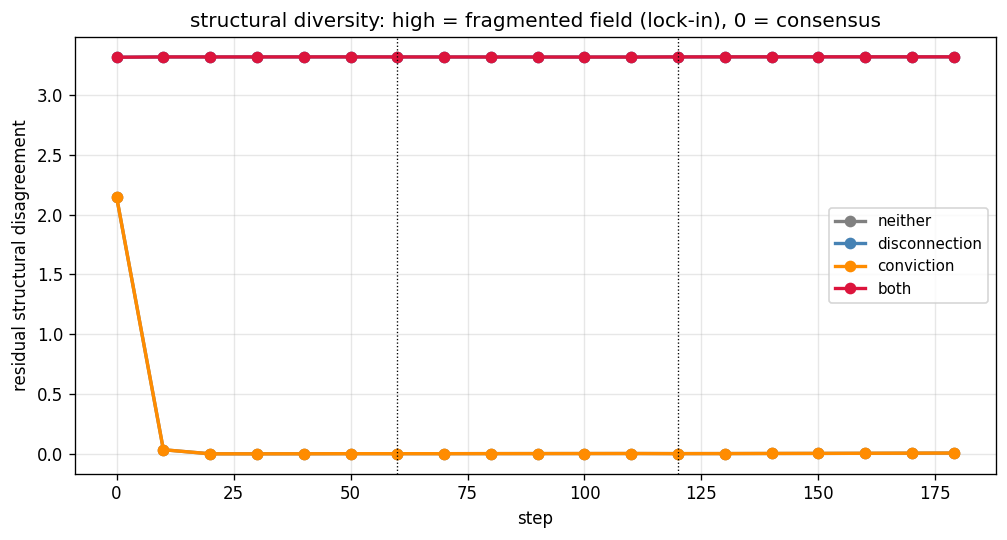

final disagreement: {'neither': 0.01, 'disconnection': 3.32, 'conviction': 0.01, 'both': 3.32}


In [7]:
dis = {c: tr[f'disagree_{c}'] for c in cells}
fig, ax = plt.subplots(figsize=(8.5, 4.6))
cmap = {'neither': '0.5', 'disconnection': 'steelblue', 'conviction': 'darkorange', 'both': 'crimson'}
for lab in cells:
    ax.plot(snap_t, dis[lab], 'o-', lw=2, color=cmap[lab], label=lab)
for tt in (int(T1), int(T2)): ax.axvline(tt, color='k', ls=':', lw=0.8)
ax.set_xlabel('step'); ax.set_ylabel('residual structural disagreement')
ax.set_title('structural diversity: high = fragmented field (lock-in), 0 = consensus')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
print('final disagreement:', {l: round(float(dis[l][-1]), 2) for l in cells})

## 6 — Expansion: the 1998 discovery as *waking a node*

The contested *edges* in this fixed-operator model accumulate uniformly (the Fisher deposit `HᵀH` is
set by the experiment, not the data — nb44's honest caveat), so where does genuine structure
learning happen? In **expansion** — proposing a commitment the menu does not contain. Lens A
(`run_cosmology_regrowth.py`) runs an agent whose 6-node menu **lacks Λ** while the world, after
`T2`, carries a hidden `dark_energy` cause coupling commitments the menu holds independent. The
agent can't represent it as one of its nodes, so its footprint surfaces as a **coherent residual in
the prediction errors**; when the residual floor `λ_max(R)` clears a trigger and holds, the agent
**wakes a new node** — the paradigm grows a dimension. This *is* exploration in the paper's sense:
not a tuned bonus, but the expected value of expanding the model. The witness: the wake fires
**after** Λ appears, never before.

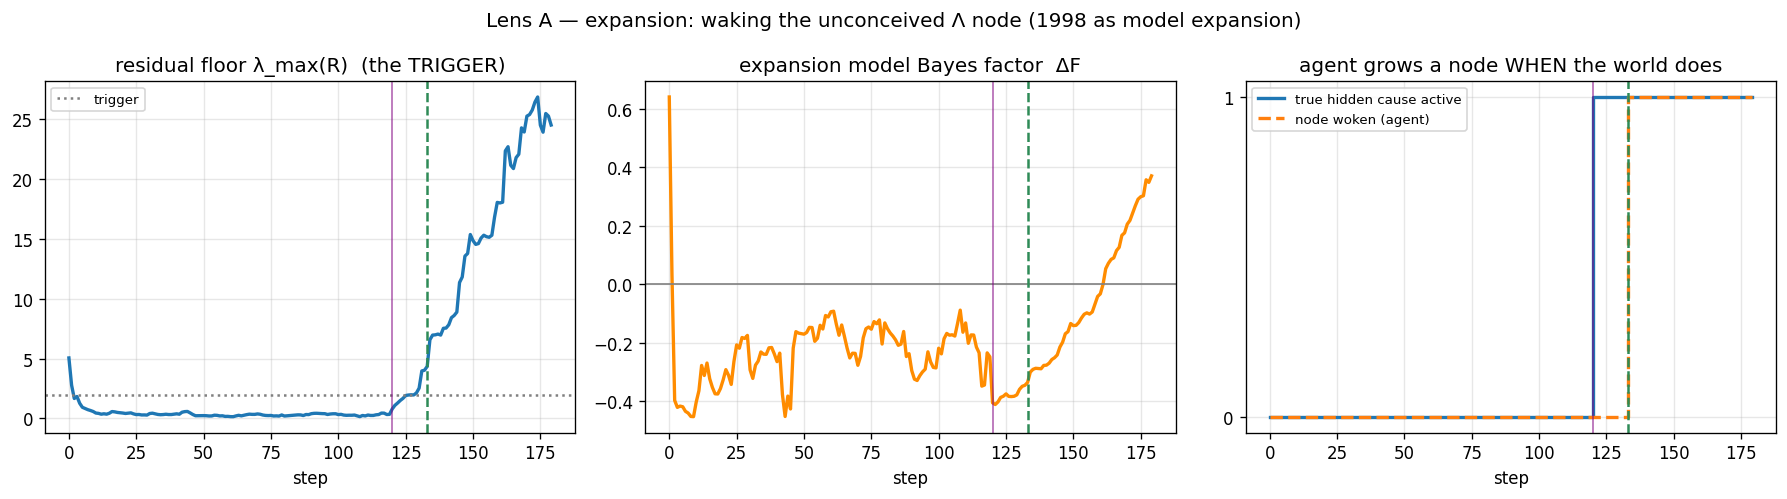

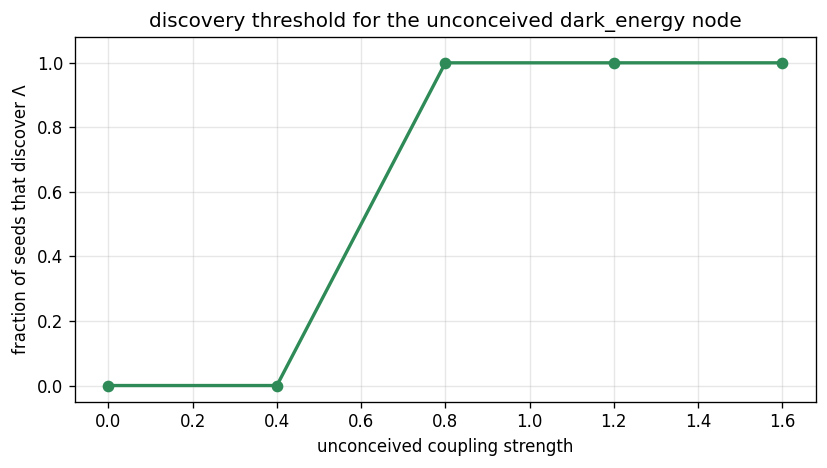

wake at t=133 (T2=120); discovery threshold ≈ coupling 0.8; null (coupling 0) never wakes.


In [8]:
rg = np.load(ROOT / 'results' / 'cosmology_regrowth' / 'simulation_arrays.npz')
floor = rg['rep_floor_t']; dF = rg['rep_delta_F_t']
na = rg['rep_n_active_t']; nw = rg['rep_n_woken_t']
ws = int(rg['rep_wake_step']); T2r = int(rg['T2'])
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
axs[0].plot(floor, lw=2); axs[0].axhline(TRIGGER, color='grey', ls=':', label='trigger')
axs[0].set_title('residual floor λ_max(R)  (the TRIGGER)'); axs[0].legend(fontsize=8)
axs[1].plot(dF, lw=2, color='darkorange'); axs[1].axhline(0, color='grey', lw=1)
axs[1].set_title('expansion model Bayes factor  ΔF')
axs[2].step(range(len(na)), na, where='post', lw=2, label='true hidden cause active')
axs[2].step(range(len(nw)), nw, where='post', lw=2, ls='--', label='node woken (agent)')
axs[2].set_yticks([0, 1]); axs[2].set_title('agent grows a node WHEN the world does'); axs[2].legend(fontsize=8)
for ax in axs:
    ax.axvline(T2r, color='purple', lw=1, alpha=0.6); ax.set_xlabel('step')
    if ws >= 0: ax.axvline(ws, color='seagreen', ls='--', lw=1.5)
plt.suptitle('Lens A — expansion: waking the unconceived Λ node (1998 as model expansion)', fontsize=12)
plt.tight_layout(); plt.show()

cp = rg['couplings']; wf = rg['wake_fraction']
fig, ax = plt.subplots(figsize=(7, 4.0))
ax.plot(cp, wf, 'o-', lw=2, color='seagreen'); ax.set_ylim(-0.05, 1.08)
ax.set_xlabel('unconceived coupling strength'); ax.set_ylabel('fraction of seeds that discover Λ')
ax.set_title('discovery threshold for the unconceived dark_energy node')
plt.tight_layout(); plt.show()
print(f'wake at t={ws} (T2={T2r}); discovery threshold ≈ coupling 0.8; null (coupling 0) never wakes.')

## Verdict

One directed Bayes net, read three ways, *is* the dark-energy turn:

* **κ = T·1** — the conservatism gradient explains why the 1998 anomaly moved Λ (cheap, one branch
  below it) and not GR (expensive, everything below it): Lakatos's protected core, derived not posited.
* **U = T·u** — a second, decoupled field of *value* on the same graph: Λ is cheap yet cherished, GR
  central yet value-neutral. The same operator on a different source.
* **Schur** — conditioning on the shared supernova manufactures the Ω_m–Λ degeneracy banana; the
  off-diagonal that wasn't there is the incommensurability fill-in.

And the bridge to nb44 closes the loop: those same two fields are the population's two levers —
**conservatism** is the stiffness that makes tracking *lag*, **conviction** is the value tilt that
makes it *lock in* (only when disconnection shields it from fusion) — while **expansion** (waking an
unconceived Λ node) is the discovery itself. *Same object, three faces, one population* — exactly the
Kuhnian "three faces of a single fact," now linear algebra rather than philosophy.

**Caveats remain in force:** this is a stylized Gaussian model, not cosmology inference; the κ/U
weights are illustrative; tracking ≠ being right; and with no forgetting, absolute late-epoch
tracking is hard by construction — read §5 as *relative*.